In [1]:
def chunk_by_char(text, chunk_size=150, chunk_overlap=20):
    chunks = []
    start_idx = 0
    
    while start_idx < len(text):
        end_idx = min(start_idx + chunk_size, len(text))
        chunk_text = text[start_idx:end_idx]
        chunks.append(chunk_text)
        
        start_idx = (
            end_idx - chunk_overlap if end_idx < len(text) else len(text)
        )
    
    return chunks

In [8]:
import re

def chunk_by_section(document_text):
    pattern = r"\n## "
    return re.split(pattern, document_text)

In [3]:
def chunk_by_sentence(text, max_sentences_per_chunk=5, overlap_sentences=1):
    sentences = re.split(r"(?<=[.!?])\s+", text)
    
    chunks = []
    start_idx = 0
    
    while start_idx < len(sentences):
        end_idx = min(start_idx + max_sentences_per_chunk, len(sentences))
        current_chunk = sentences[start_idx:end_idx]
        chunks.append(" ".join(current_chunk))
        
        start_idx += max_sentences_per_chunk - overlap_sentences
        
        if start_idx < 0:
            start_idx = 0
    
    return chunks

In [5]:
chunk_by_char(r'C:\Users\SriniAchuthan\Downloads\report.md',150,20)

['C:\\Users\\SriniAchuthan\\Downloads\\report.md']

In [11]:
chunks = chunk_by_section(r'C:\Users\SriniAchuthan\Downloads\report.md')


for i, chunk in enumerate(chunks):
      lines = chunk.strip().split('\n')
      title = lines[0]
      preview = lines[2][:100] if len(lines) > 2 else ""
      print(f"\nChunk {i+1}: {title}")
      print(f"Preview : {preview}...")


Chunk 1: C:\Users\SriniAchuthan\Downloads\report.md
Preview : ...


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.preprocessing import PolynomialFeatures

data = pd.read_csv(r'C:\Users\SriniAchuthan\OneDrive\Desktop\Python\vgsales.csv\vgsales.csv')
print(data)

        Rank                                              Name Platform  \
0          1                                        Wii Sports      Wii   
1          2                                 Super Mario Bros.      NES   
2          3                                    Mario Kart Wii      Wii   
3          4                                 Wii Sports Resort      Wii   
4          5                          Pokemon Red/Pokemon Blue       GB   
...      ...                                               ...      ...   
16593  16596                Woody Woodpecker in Crazy Castle 5      GBA   
16594  16597                     Men in Black II: Alien Escape       GC   
16595  16598  SCORE International Baja 1000: The Official Game      PS2   
16596  16599                                        Know How 2       DS   
16597  16600                                  Spirits & Spells      GBA   

         Year         Genre   Publisher  NA_Sales  EU_Sales  JP_Sales  \
0      2006.0        Sport

In [15]:
print(data.head)


<bound method NDFrame.head of         Rank                                              Name Platform  \
0          1                                        Wii Sports      Wii   
1          2                                 Super Mario Bros.      NES   
2          3                                    Mario Kart Wii      Wii   
3          4                                 Wii Sports Resort      Wii   
4          5                          Pokemon Red/Pokemon Blue       GB   
...      ...                                               ...      ...   
16593  16596                Woody Woodpecker in Crazy Castle 5      GBA   
16594  16597                     Men in Black II: Alien Escape       GC   
16595  16598  SCORE International Baja 1000: The Official Game      PS2   
16596  16599                                        Know How 2       DS   
16597  16600                                  Spirits & Spells      GBA   

         Year         Genre   Publisher  NA_Sales  EU_Sales  JP_Sales

In [16]:
print(data.tail)

<bound method NDFrame.tail of         Rank                                              Name Platform  \
0          1                                        Wii Sports      Wii   
1          2                                 Super Mario Bros.      NES   
2          3                                    Mario Kart Wii      Wii   
3          4                                 Wii Sports Resort      Wii   
4          5                          Pokemon Red/Pokemon Blue       GB   
...      ...                                               ...      ...   
16593  16596                Woody Woodpecker in Crazy Castle 5      GBA   
16594  16597                     Men in Black II: Alien Escape       GC   
16595  16598  SCORE International Baja 1000: The Official Game      PS2   
16596  16599                                        Know How 2       DS   
16597  16600                                  Spirits & Spells      GBA   

         Year         Genre   Publisher  NA_Sales  EU_Sales  JP_Sales

In [17]:
import seaborn as sns
print(data.dtypes)

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


In [19]:
print(data.shape)

(16598, 11)


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [21]:
data.isnull()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
16593,False,False,False,False,False,False,False,False,False,False,False
16594,False,False,False,False,False,False,False,False,False,False,False
16595,False,False,False,False,False,False,False,False,False,False,False
16596,False,False,False,False,False,False,False,False,False,False,False


In [22]:
data.isnull().sum

<bound method DataFrame.sum of         Rank   Name  Platform   Year  Genre  Publisher  NA_Sales  EU_Sales  \
0      False  False     False  False  False      False     False     False   
1      False  False     False  False  False      False     False     False   
2      False  False     False  False  False      False     False     False   
3      False  False     False  False  False      False     False     False   
4      False  False     False  False  False      False     False     False   
...      ...    ...       ...    ...    ...        ...       ...       ...   
16593  False  False     False  False  False      False     False     False   
16594  False  False     False  False  False      False     False     False   
16595  False  False     False  False  False      False     False     False   
16596  False  False     False  False  False      False     False     False   
16597  False  False     False  False  False      False     False     False   

       JP_Sales  Other_Sales  Gl

In [28]:
df = data.dropna()
print(df)

        Rank                                              Name Platform  \
0          1                                        Wii Sports      Wii   
1          2                                 Super Mario Bros.      NES   
2          3                                    Mario Kart Wii      Wii   
3          4                                 Wii Sports Resort      Wii   
4          5                          Pokemon Red/Pokemon Blue       GB   
...      ...                                               ...      ...   
16593  16596                Woody Woodpecker in Crazy Castle 5      GBA   
16594  16597                     Men in Black II: Alien Escape       GC   
16595  16598  SCORE International Baja 1000: The Official Game      PS2   
16596  16599                                        Know How 2       DS   
16597  16600                                  Spirits & Spells      GBA   

         Year         Genre   Publisher  NA_Sales  EU_Sales  JP_Sales  \
0      2006.0        Sport

In [42]:
X = df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']]
y = df['Global_Sales']
X_train,y_train,X_test,y_test = train_test_split(X,y,test_size=1/3,random_state=42)

print('Training Set:',y_train)
print('Testing Set:',y_test)

Training Set:        NA_Sales  EU_Sales  JP_Sales  Other_Sales
3527       0.52      0.01      0.00         0.04
12216      0.00      0.04      0.02         0.00
7940       0.00      0.00      0.19         0.00
3030       0.44      0.16      0.00         0.07
7144       0.16      0.06      0.00         0.00
...         ...       ...       ...          ...
3970       0.20      0.26      0.00         0.04
13122      0.00      0.04      0.00         0.01
10871      0.05      0.04      0.00         0.01
7834       0.15      0.03      0.00         0.01
4478       0.31      0.12      0.00         0.01

[5431 rows x 4 columns]
Testing Set: 3527     0.57
12216    0.07
7940     0.19
3030     0.67
7144     0.22
         ... 
3970     0.50
13122    0.05
10871    0.09
7834     0.19
4478     0.44
Name: Global_Sales, Length: 5431, dtype: float64


In [33]:
print(df.values)

[[1 'Wii Sports' 'Wii' ... 3.77 8.46 82.74]
 [2 'Super Mario Bros.' 'NES' ... 6.81 0.77 40.24]
 [3 'Mario Kart Wii' 'Wii' ... 3.79 3.31 35.82]
 ...
 [16598 'SCORE International Baja 1000: The Official Game' 'PS2' ... 0.0
  0.0 0.01]
 [16599 'Know How 2' 'DS' ... 0.0 0.0 0.01]
 [16600 'Spirits & Spells' 'GBA' ... 0.0 0.0 0.01]]


In [34]:
print(df.describe())

               Rank          Year      NA_Sales      EU_Sales      JP_Sales  \
count  16291.000000  16291.000000  16291.000000  16291.000000  16291.000000   
mean    8290.190228   2006.405561      0.265647      0.147731      0.078833   
std     4792.654450      5.832412      0.822432      0.509303      0.311879   
min        1.000000   1980.000000      0.000000      0.000000      0.000000   
25%     4132.500000   2003.000000      0.000000      0.000000      0.000000   
50%     8292.000000   2007.000000      0.080000      0.020000      0.000000   
75%    12439.500000   2010.000000      0.240000      0.110000      0.040000   
max    16600.000000   2020.000000     41.490000     29.020000     10.220000   

        Other_Sales  Global_Sales  
count  16291.000000  16291.000000  
mean       0.048426      0.540910  
std        0.190083      1.567345  
min        0.000000      0.010000  
25%        0.000000      0.060000  
50%        0.010000      0.170000  
75%        0.040000      0.480000  


In [36]:
data2 = pd.DataFrame(df.describe())
print(data2)

               Rank          Year      NA_Sales      EU_Sales      JP_Sales  \
count  16291.000000  16291.000000  16291.000000  16291.000000  16291.000000   
mean    8290.190228   2006.405561      0.265647      0.147731      0.078833   
std     4792.654450      5.832412      0.822432      0.509303      0.311879   
min        1.000000   1980.000000      0.000000      0.000000      0.000000   
25%     4132.500000   2003.000000      0.000000      0.000000      0.000000   
50%     8292.000000   2007.000000      0.080000      0.020000      0.000000   
75%    12439.500000   2010.000000      0.240000      0.110000      0.040000   
max    16600.000000   2020.000000     41.490000     29.020000     10.220000   

        Other_Sales  Global_Sales  
count  16291.000000  16291.000000  
mean       0.048426      0.540910  
std        0.190083      1.567345  
min        0.000000      0.010000  
25%        0.000000      0.060000  
50%        0.010000      0.170000  
75%        0.040000      0.480000  


Accuracy: 0.22829088677508438

Classification Report:
              precision    recall  f1-score   support

      Action       0.23      0.63      0.33       644
   Adventure       0.29      0.33      0.31       259
    Fighting       0.00      0.00      0.00       149
        Misc       0.23      0.03      0.05       378
    Platform       0.16      0.08      0.11       182
      Puzzle       0.08      0.04      0.05       108
      Racing       0.00      0.00      0.00       250
Role-Playing       0.23      0.38      0.29       287
     Shooter       0.00      0.00      0.00       255
  Simulation       0.00      0.00      0.00       172
      Sports       0.23      0.26      0.24       441
    Strategy       0.00      0.00      0.00       134

    accuracy                           0.23      3259
   macro avg       0.12      0.15      0.12      3259
weighted avg       0.16      0.23      0.16      3259



C:\Users\SriniAchuthan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\SriniAchuthan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\SriniAchuthan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

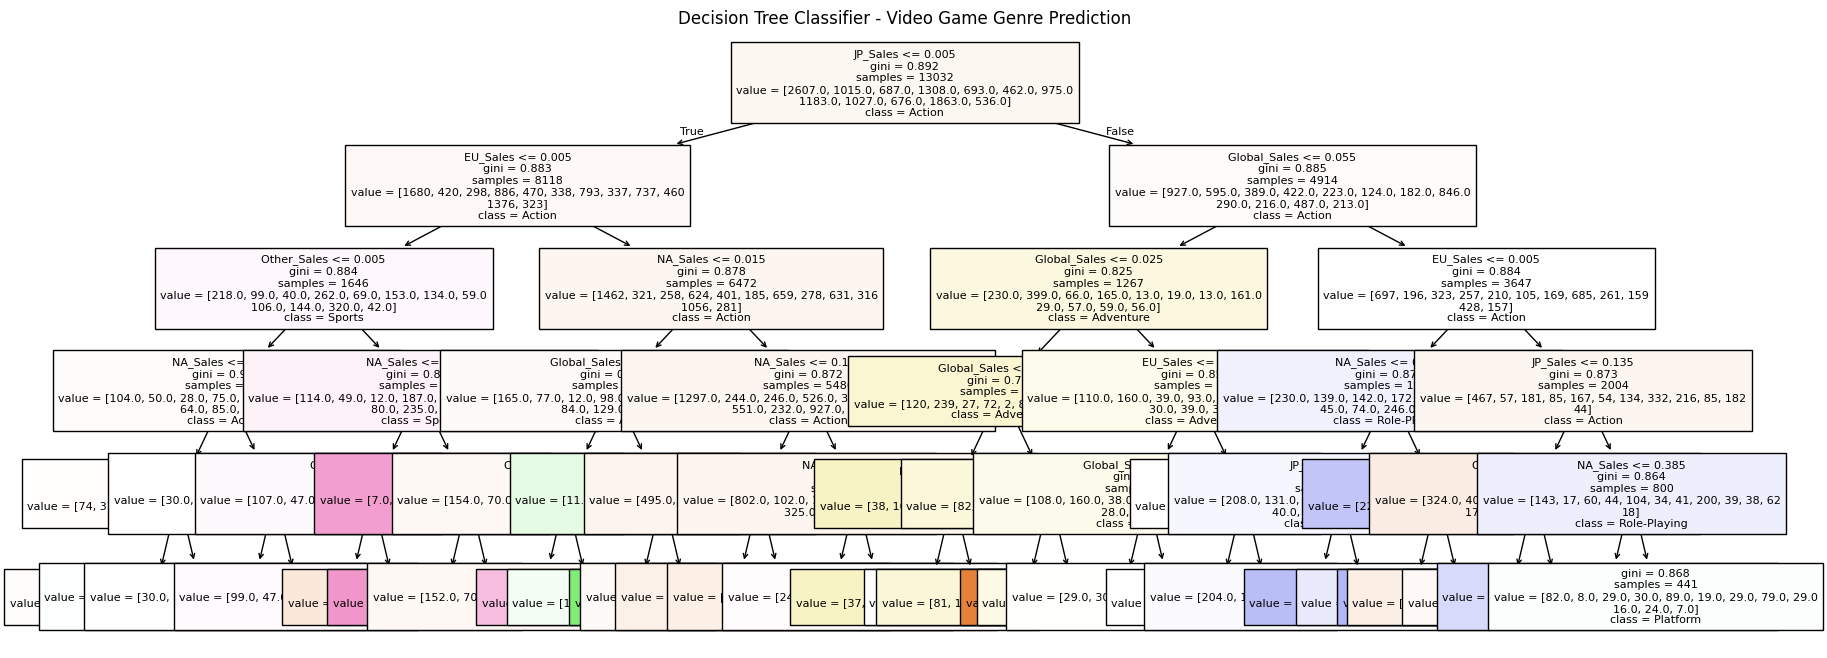

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

  # 1. Load Data
df = pd.read_csv(r'C:\Users\SriniAchuthan\OneDrive\Desktop\Python\vgsales.csv\vgsales.csv')
df = df.dropna()

  # 2. Features and Target
X = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']]
y = df['Genre']

  # 3. Encode Target
le = LabelEncoder()
y = le.fit_transform(y)

  # 4. Split Data
X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
  )

  # 5. Train Model
clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

  # 6. Predict
y_pred = clf.predict(X_test)

  # 7. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

  # 8. Visualize Tree
plt.figure(figsize=(20, 8))
plot_tree(clf,
            feature_names=X.columns.tolist(),
            class_names=le.classes_,
            filled=True,
            fontsize=8)
plt.title("Decision Tree Classifier - Video Game Genre Prediction")
plt.show()


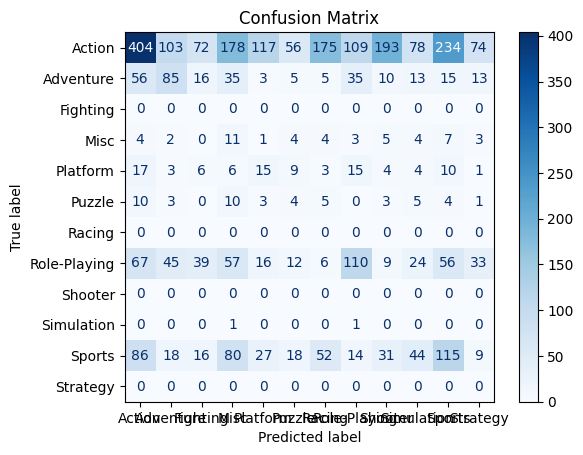

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_pred,y_test)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()